In [1]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from common import FEATURES_OUTFILE
from dmm.initialisation import get_features
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [2]:
# Helper function to filter columns
def filter_relevant_columns(df):
    return [col for col in df.columns if col[0] in {"pERK_Y204_obs", "pMEK_S222_obs", "pERBB2_Y1248_obs"}]

# Modified RMSE computation function
def masked_rmse(true_df, pred_df):
    # print("Fraction of NaN values in true_df: ", np.isnan(true_df).sum().sum() / true_df.size)
    squared_errors = (true_df - pred_df) ** 2
    rmse = np.sqrt(np.nanmean(squared_errors.values))
    return rmse

### Usual CV split (0of5-...-4of5)

In [3]:
features, rmses = {}, {}
for samples in [f"{n}of5" for n in range(5)]:
    features[samples] = {}
    rmses[samples] = {}

    # Set up minimal conf
    conf_dict = {
        "model": "EGFR_MAPK",
        "data": "dream_cytof",
        "samples": samples,
        "features": "all",
        "context": "cytof_dynamic",
    }

    # Define filepath for features file
    features_filepath = FEATURES_OUTFILE.format(
        **{**conf_dict, **dict(dataset = "{dataset}")}
    )

    # Define datasets and load features
    settings = {
            "train": ["train"],
            "test": ["val"],
            "train+test": ["train", "val"],
    }

    temp_features_samples = get_features(features_filepath=features_filepath, datasets=settings["train+test"])
    for key in temp_features_samples.keys():
        temp_features_samples[key].columns = [ast.literal_eval(col) if isinstance(col, str) and col.startswith('(') else col for col in temp_features_samples[key].columns]

    knn_imputer = KNNImputer()
    # Fit on train
    knn_imputer.fit(temp_features_samples["train"])
    # Transform train and val and save imputed features to dict
    features[samples]["train"] = knn_imputer.transform(temp_features_samples["train"])
    features[samples]["val"] = knn_imputer.transform(temp_features_samples["val"])

    pipeline = Pipeline([
        ('scaler', StandardScaler(with_std=False, with_mean=False)),
        ('pca', PCA(
            n_components=2,
            whiten=True,
        ))
    ])

    # fit on training features
    pipeline.fit(features[samples]["train"])

    # transform both train and val
    transformed_features = {
        dataset: pd.DataFrame(
            pipeline.transform(features[samples][dataset]),
            index=temp_features_samples[dataset].index,
            columns=[f'pca_{i}' for i in range(pipeline.named_steps['pca'].n_components_)]
        )
        for dataset in features[samples].keys()
    }

    # No.1: try to recover by inverting PCA
    recovered_features = {
        dataset: pd.DataFrame(
            pipeline.inverse_transform(transformed_features[dataset]),
            index=temp_features_samples[dataset].index,
            columns=temp_features_samples[dataset].columns
        )
        for dataset in features[samples].keys()
    }

    # No.2: try to recover by fitting a linear regression between the original features and the PCA transformed features
    lr = LinearRegression()
    lr.fit(transformed_features["train"], features[samples]["train"])
    lr_pred = {
        dataset: pd.DataFrame(
            lr.predict(transformed_features[dataset]),
            index=temp_features_samples[dataset].index,
            columns=temp_features_samples[dataset].columns
        )
        for dataset in features[samples].keys()
    }

    # Compute RMSE w.r.t. original validation features, filtered
    for dataset in ["train", "val"]:
        # Get the columns that match pERK, pMEK, pERBB2
        relevant_cols = filter_relevant_columns(temp_features_samples[dataset])

        # Compute RMSEs only where data existed and for selected markers
        rmses[samples][dataset] = {
            "pca": masked_rmse(
                temp_features_samples[dataset][relevant_cols],
                recovered_features[dataset][relevant_cols],
            ),
            "lr": masked_rmse(
                temp_features_samples[dataset][relevant_cols],
                lr_pred[dataset][relevant_cols],
            )
        }
        for method in ["pca", "lr"]:
            print(f"RMSE ({method}) for {dataset} with {samples} samples: {rmses[samples][dataset][method]:.2f}")



RMSE (pca) for train with 0of5 samples: 0.32
RMSE (lr) for train with 0of5 samples: 0.32
RMSE (pca) for val with 0of5 samples: 0.30
RMSE (lr) for val with 0of5 samples: 0.30
RMSE (pca) for train with 1of5 samples: 0.32
RMSE (lr) for train with 1of5 samples: 0.32
RMSE (pca) for val with 1of5 samples: 0.38
RMSE (lr) for val with 1of5 samples: 0.38
RMSE (pca) for train with 2of5 samples: 0.32
RMSE (lr) for train with 2of5 samples: 0.32
RMSE (pca) for val with 2of5 samples: 0.32
RMSE (lr) for val with 2of5 samples: 0.32
RMSE (pca) for train with 3of5 samples: 0.32
RMSE (lr) for train with 3of5 samples: 0.32
RMSE (pca) for val with 3of5 samples: 0.45
RMSE (lr) for val with 3of5 samples: 0.45
RMSE (pca) for train with 4of5 samples: 0.31
RMSE (lr) for train with 4of5 samples: 0.31
RMSE (pca) for val with 4of5 samples: 0.56
RMSE (lr) for val with 4of5 samples: 0.56


In [4]:
# Exactly identical results in simply inverting PCA and using a linear regression from original features to compressed ones
print("PCA, train: ", np.mean([rmses[i]["train"]["pca"] for i in rmses.keys()]))
print("PCA, val: ", np.mean([rmses[i]["val"]["pca"] for i in rmses.keys()]))

print("LR, train: ", np.mean([rmses[i]["train"]["lr"] for i in rmses.keys()]))
print("LR, val: ", np.mean([rmses[i]["val"]["lr"] for i in rmses.keys()]))

PCA, train:  0.3166397470748833
PCA, val:  0.40089728609916114
LR, train:  0.3166397470748833
LR, val:  0.4008972860991612


### Forming a leave-one-out CV split for every possible cell-line in our dataset (with subchallenge II added - 52 cell-lines overall)

In [5]:
# Use only a single sample split
samples = "0of5"
rmses = {}

# Set up config
conf_dict = {
    "model": "EGFR_MAPK",
    "data": "dream_cytof",
    "samples": samples,
    "features": "all",
    "context": "cytof_dynamic",
}

# Load both train and val data for 0of5
features_filepath = FEATURES_OUTFILE.format(
    **{**conf_dict, **dict(dataset="{dataset}")}
)
settings = {
    "train": ["train"],
    "test": ["val"],
    "train+test": ["train", "val"],
}

temp_features_samples = get_features(
    features_filepath=features_filepath,
    datasets=settings["train+test"]
)
for key in temp_features_samples.keys():
    temp_features_samples[key].columns = [ast.literal_eval(col) if isinstance(col, str) and col.startswith('(') else col for col in temp_features_samples[key].columns]

# Concatenate train and val
all_features = pd.concat(temp_features_samples.values())
cell_lines = all_features.index.unique()

# Loop through each cell-line: leave it out, train on the rest
for val_cell_line in cell_lines:
    rmses[val_cell_line] = {}

    # Split into train/val
    train_idx = all_features.index != val_cell_line
    val_idx = all_features.index == val_cell_line

    train_features = all_features.loc[train_idx]
    val_features = all_features.loc[val_idx]

    # Impute using KNN on training data
    knn_imputer = KNNImputer()
    knn_imputer.fit(train_features)
    imputed_train = knn_imputer.transform(train_features)
    imputed_val = knn_imputer.transform(val_features)

    # Fit PCA pipeline on training data
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_std=False, with_mean=False)),
        ('pca', PCA(n_components=2, whiten=True))
    ])
    pipeline.fit(imputed_train)

    # Transform both train and val
    transformed_train = pipeline.transform(imputed_train)
    transformed_val = pipeline.transform(imputed_val)

    # Compute RMSE w.r.t. original validation features, filtered
    for dataset, original_features, transformed_features in zip(
            ["train", "val"],
            [train_features, val_features],
            [transformed_train, transformed_val]
    ):
        # Get the columns that match pERK, pMEK, pERBB2
        relevant_cols = filter_relevant_columns(original_features)

        # Compute RMSEs only where data existed and for selected markers
        rmses[val_cell_line][dataset] = masked_rmse(
            original_features[relevant_cols],
            pd.DataFrame(
                pipeline.inverse_transform(transformed_features),
                index=original_features.index,
                columns=original_features.columns
            )[relevant_cols],
        )

# Convert to DataFrame
rmse_df = pd.DataFrame.from_dict(rmses, orient='index')
rmse_df.index.name = "val_cell_line"
rmse_df = rmse_df.reset_index()

In [6]:
rmse_df

,val_cell_line,train,val
0,c184A1,0.317721,0.338366
1,c184B5,0.316123,0.431809
2,cBT20,0.317719,0.379811
3,cBT474,0.316032,0.388794
4,cBT483,0.318355,0.304092
5,cBT549,0.320118,0.216247
6,cCAL148,0.317290,0.370800
7,cCAL51,0.319321,0.271619
8,cCAL851,0.320410,0.193339
9,cDU4475,0.307861,0.672200


/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


Text(0, 0.5, 'RMSE')

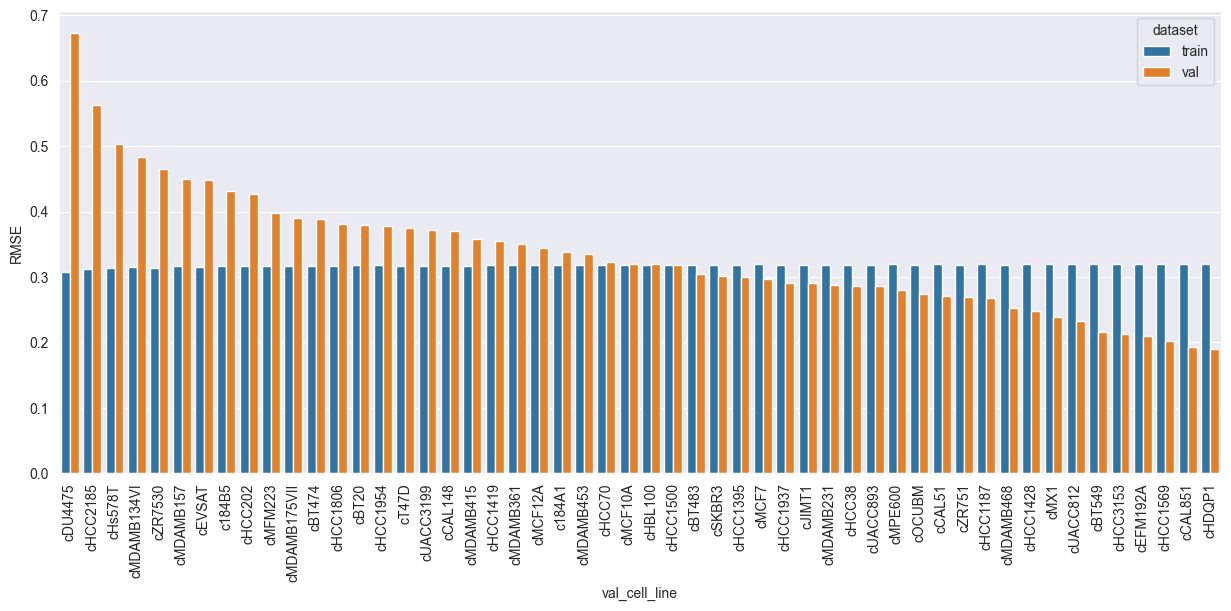

In [7]:
plt.figure(figsize=(15, 6))
sns.barplot(
    data=rmse_df.sort_values(by="val", ascending=False).melt(
        id_vars='val_cell_line',
        var_name='dataset',
        value_name='rmse'
    ),
    x="val_cell_line",
    y="rmse",
    hue="dataset",
)
plt.xticks(rotation=90)
plt.ylabel("RMSE")

In [8]:
rmse_df.sort_values(by="val", ascending=False).head(5).val_cell_line.values

array(['cDU4475', 'cHCC2185', 'cHs578T', 'cMDAMB134VI', 'cZR7530'],
      dtype=object)

In [9]:
rmse_df["gap"] = rmse_df["val"] - rmse_df["train"]
rmse_df.sort_values(by="gap", ascending=False).head(5).val_cell_line.values

array(['cDU4475', 'cHCC2185', 'cHs578T', 'cMDAMB134VI', 'cZR7530'],
      dtype=object)